### Time Series Pattern Classification

#### Objective
The goal of this assignment is to analyze time-series data of shape `(batch, 10, 2)`, discover repeating temporal patterns in **class 1**, and build a binary classification model that can distinguish class `0` and class `1` samples.

#### Assignment Requirements
The notebook covers:
- Feature Analysis
- Model Training
- Model Selection
- Model Evaluation
- Production Readiness and Limitations

#### Important Constraint
SMOTE is not used because the problem contains temporal dependencies, and synthetic oversampling could distort the sequence structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

Load Data

In [5]:
X = np.load("../data/X.npz")["arr_0"]
y = np.load("../data/y.npz")["arr_0"]

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (999991, 10, 2)
Shape of y:  (999991,)


TO be safe - check for any missing values

In [48]:
# Check for missing values in the dataset
print("Missing values in X:", np.isnan(X).sum())
print("Missing values in y:", np.isnan(y).sum())

Missing values in X: 0
Missing values in y: 0


Basic Inspection

In [6]:
print("First sample shape:", X[0].shape)
print("\nFirst sample:\n", X[0])
print("\nUnique labels:", np.unique(y))
print("\nClass counts:", Counter(y))

First sample shape: (10, 2)

First sample:
 [[  7.37123228  -1.94677024]
 [-18.42842376  -5.09767874]
 [ -1.43933599  -9.91950072]
 [ -2.79447095  -9.62893966]
 [-18.08327104  16.70333388]
 [-19.03699992  17.74685937]
 [ -3.16413771  -1.02089318]
 [  6.33031237  -2.01437082]
 [-10.59985909  -2.1739294 ]
 [ -3.5635373   -8.66233473]]

Unique labels: [0. 1.]

Class counts: Counter({np.float64(0.0): 999298, np.float64(1.0): 693})


Class distribution table

In [ ]:
class_counts = pd.Series(y).value_counts().sort_index()                             #how many samples belong to each class
class_percent = pd.Series(y).value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent.round(4)
})

class_summary.index.name = "class"
class_summary

,count,percentage
class,,
0.0,999298,99.9307
1.0,693,0.0693


#### Initial Observations

- The dataset contains a very large number of samples.
- Each sample is a short multivariate time series with 10 time steps and 2 dimensions.
- The target is binary: class 0 and class 1.
- Class 1 is extremely rare compared to class 0, so the dataset is highly imbalanced.
- Because the minority class is rare and the data is temporal, the analysis must focus on discovering stable sequence patterns rather than relying on synthetic oversampling.

##### Class Imbalance

The dataset is highly imbalanced:

- Class 0: ~99.93%
- Class 1: ~0.07%

Because of this imbalance:
- Accuracy is not an informative metric.
- Evaluation will focus on **Precision, Recall, F1-score, and PR-AUC**.
- Models will use **class weighting** to compensate for the imbalance.

Separate class 0 and class 1 indices

In [9]:
#position of class samples in dataset
class0_idx = np.where(y == 0)[0]        #np.where() returns a tuple, (array([0,2,3]),)  |  So [0] extracts the array inside, [0,2,3]
class1_idx = np.where(y == 1)[0]

print("Number of class 0 samples:", len(class0_idx))
print("Number of class 1 samples:", len(class1_idx))

Number of class 0 samples: 999298
Number of class 1 samples: 693


Inspect a few class 1 samples

In [10]:
for i in range(3):
    print(f"\nClass 1 sample index: {class1_idx[i]}")
    print(X[class1_idx[i]])


Class 1 sample index: 7882
[[ -2.75303681  -4.6491321 ]
 [ -3.45476136  -9.03654515]
 [ 11.87789865   0.55809885]
 [-15.75800829  -6.80038371]
 [ 14.0137616  -12.16455052]
 [ 20.05801103  -5.1241688 ]
 [ -4.05498555 -10.79821021]
 [ -4.23520959  -1.31881298]
 [ -3.831798    -1.76211803]
 [ -4.21602768 -11.44281674]]

Class 1 sample index: 7883
[[ -3.45476136  -9.03654515]
 [ 11.87789865   0.55809885]
 [-15.75800829  -6.80038371]
 [ 14.0137616  -12.16455052]
 [ 20.05801103  -5.1241688 ]
 [ -4.05498555 -10.79821021]
 [ -4.23520959  -1.31881298]
 [ -3.831798    -1.76211803]
 [ -4.21602768 -11.44281674]
 [ -8.86038996  -3.09925031]]

Class 1 sample index: 7884
[[ 11.87789865   0.55809885]
 [-15.75800829  -6.80038371]
 [ 14.0137616  -12.16455052]
 [ 20.05801103  -5.1241688 ]
 [ -4.05498555 -10.79821021]
 [ -4.23520959  -1.31881298]
 [ -3.831798    -1.76211803]
 [ -4.21602768 -11.44281674]
 [ -8.86038996  -3.09925031]
 [-16.99173139  -5.78773324]]


Inspect a few class 0 samples

In [15]:
for i in range(3):
    print(f"\nClass 0 sample index: {class0_idx[i]}")
    print(X[class0_idx[i]])


Class 0 sample index: 0
[[  7.37123228  -1.94677024]
 [-18.42842376  -5.09767874]
 [ -1.43933599  -9.91950072]
 [ -2.79447095  -9.62893966]
 [-18.08327104  16.70333388]
 [-19.03699992  17.74685937]
 [ -3.16413771  -1.02089318]
 [  6.33031237  -2.01437082]
 [-10.59985909  -2.1739294 ]
 [ -3.5635373   -8.66233473]]

Class 0 sample index: 1
[[-18.42842376  -5.09767874]
 [ -1.43933599  -9.91950072]
 [ -2.79447095  -9.62893966]
 [-18.08327104  16.70333388]
 [-19.03699992  17.74685937]
 [ -3.16413771  -1.02089318]
 [  6.33031237  -2.01437082]
 [-10.59985909  -2.1739294 ]
 [ -3.5635373   -8.66233473]
 [-15.54216268  -5.52364592]]

Class 0 sample index: 2
[[ -1.43933599  -9.91950072]
 [ -2.79447095  -9.62893966]
 [-18.08327104  16.70333388]
 [-19.03699992  17.74685937]
 [ -3.16413771  -1.02089318]
 [  6.33031237  -2.01437082]
 [-10.59985909  -2.1739294 ]
 [ -3.5635373   -8.66233473]
 [-15.54216268  -5.52364592]
 [-13.32121154  19.18980526]]


#### Exploratory Pattern Analysis

To understand the temporal behaviour of the sequences, we visualize samples from both classes.

Each sequence contains:
- 10 time steps
- 2 features per time step

By plotting these sequences we can identify whether **class 1 samples share repeating temporal patterns** that differentiate them from class 0.

Create a plot Function

In [20]:
def plot_sequence(sample):

    f1 = sample[:, 0]
    f2 = sample[:, 1]

    plt.plot(range(10), f1, marker="o", label="Feature 1")
    plt.plot(range(10), f2, marker="o", label="Feature 2")

    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()

Plot Class 1 sequence 

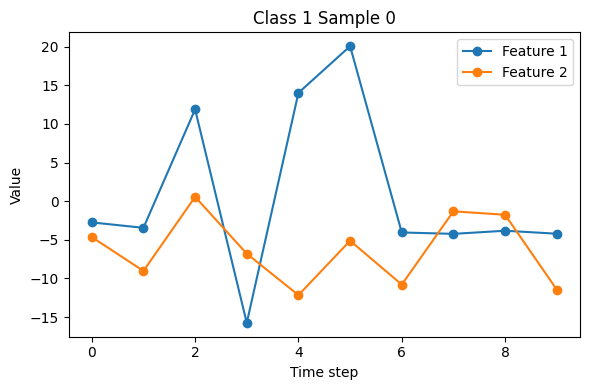

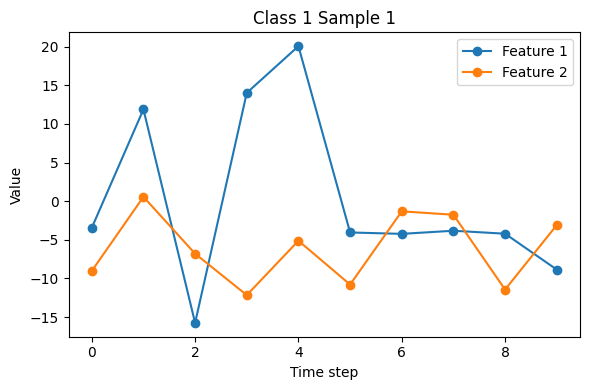

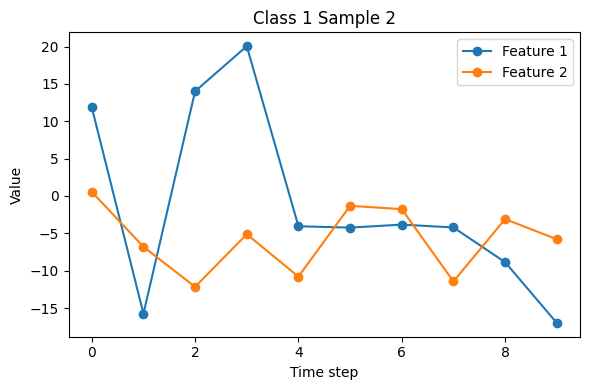

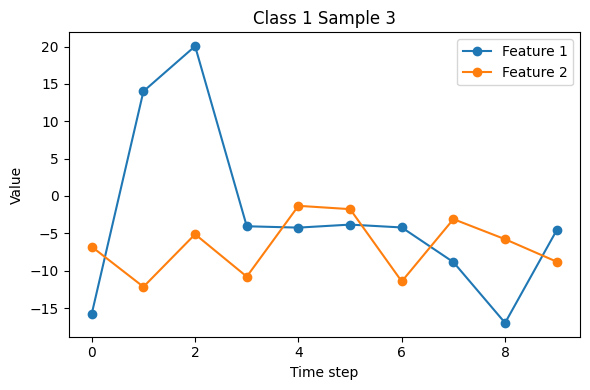

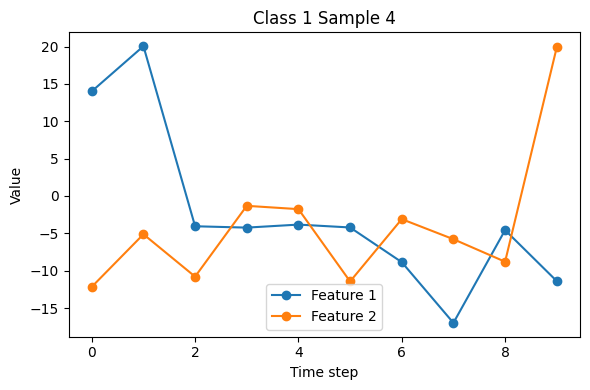

In [21]:
for i in range(5):
    plt.figure(figsize=(6, 4))
    plot_sequence(X[class1_idx[i]])
    plt.title(f"Class 1 Sample {i}")
    plt.tight_layout()
    plt.show()
    plt.close()

Plot Class-0 sequences

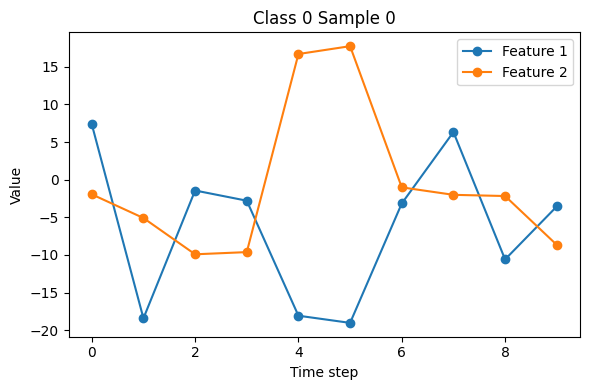

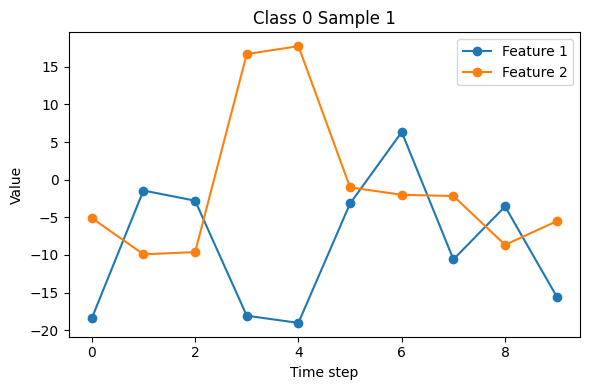

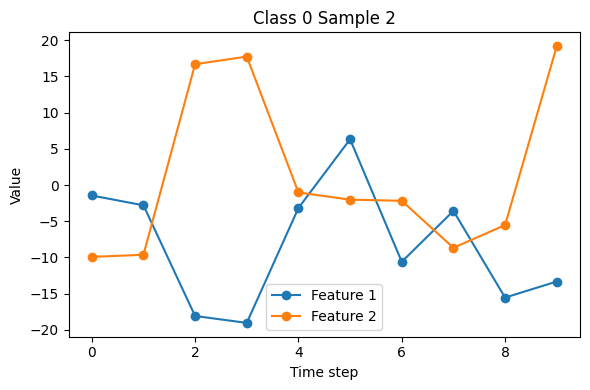

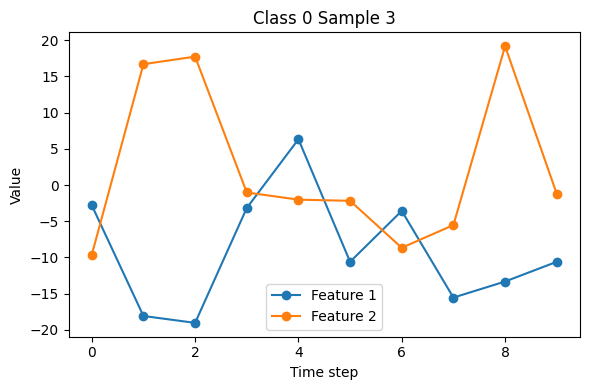

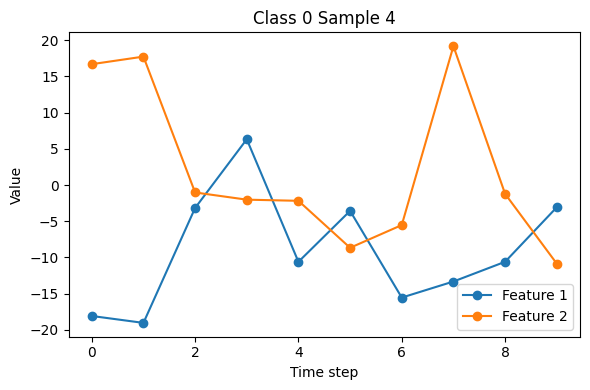

In [22]:
for i in range(5):
    plt.figure(figsize=(6, 4))
    plot_sequence(X[class0_idx[i]])
    plt.title(f"Class 0 Sample {i}")
    plt.tight_layout()
    plt.show()
    plt.close()

Compare average pattern per class

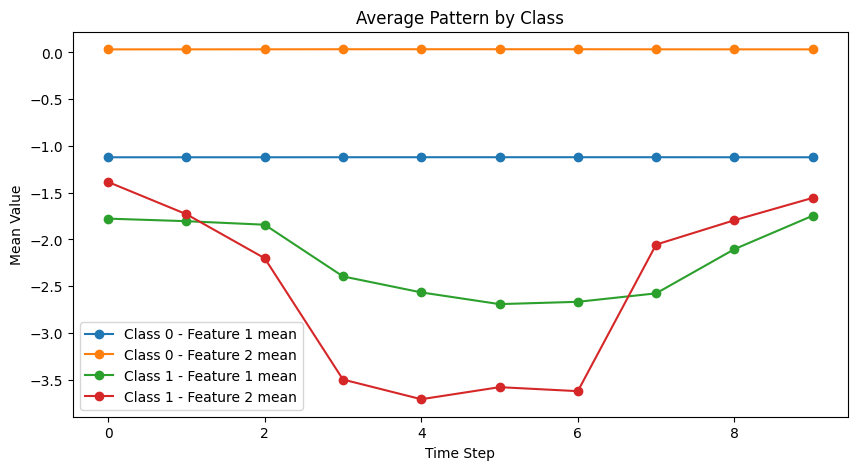

In [29]:
# Compute the average time-series pattern for each class by taking the mean across all samples
# Result shape becomes (10,2) representing mean Feature1 and Feature2 at each time step
class0_mean = X[y == 0].mean(axis=0)
class1_mean = X[y == 1].mean(axis=0)

plt.figure(figsize=(10,5))

plt.plot(class0_mean[:,0], marker="o", label="Class 0 - Feature 1 mean")
plt.plot(class0_mean[:,1], marker="o", label="Class 0 - Feature 2 mean")

plt.plot(class1_mean[:,0], marker="o", label="Class 1 - Feature 1 mean")
plt.plot(class1_mean[:,1], marker="o", label="Class 1 - Feature 2 mean")

plt.title("Average Pattern by Class")
plt.xlabel("Time Step")
plt.ylabel("Mean Value")
plt.legend()
plt.show()

# The average sequences show that class-1 samples exhibit a noticeable dip around the middle time steps (4–6), whereas class-0 sequences remain relatively stable across time. This suggests a temporal pattern that can help the model distinguish the two classes.

Compare variability 

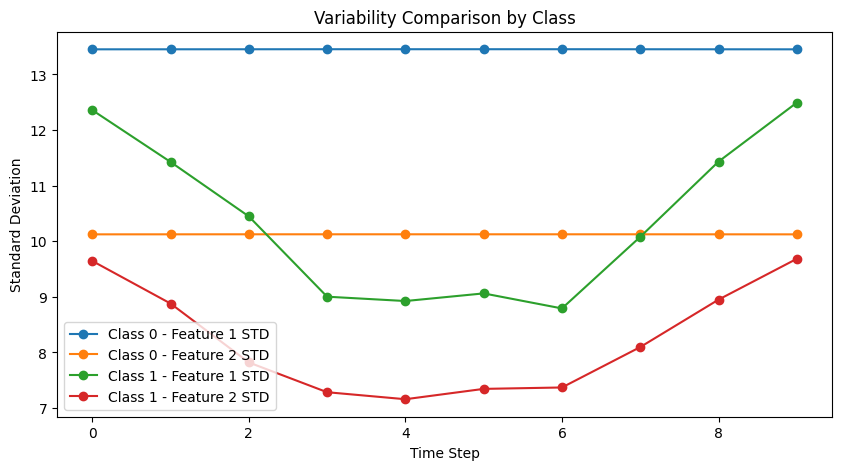

In [31]:
# Compute the variability (standard deviation) of sequences for each class across all samples at each time step. 
# This measures how much the feature values vary within each class over time.
class0_std = X[y == 0].std(axis=0)
class1_std = X[y == 1].std(axis=0)

plt.figure(figsize=(10,5))

plt.plot(class0_std[:,0], marker="o", label="Class 0 - Feature 1 STD")
plt.plot(class0_std[:,1], marker="o", label="Class 0 - Feature 2 STD")

plt.plot(class1_std[:,0], marker="o", label="Class 1 - Feature 1 STD")
plt.plot(class1_std[:,1], marker="o", label="Class 1 - Feature 2 STD")

plt.title("Variability Comparison by Class")
plt.xlabel("Time Step")
plt.ylabel("Standard Deviation")
plt.legend()
plt.show()

# The variability plot shows how much the values fluctuate across samples at each time step. Class-0 sequences exhibit relatively stable variability across time, whereas class-1 sequences show a change in variability around the middle time steps. This supports the earlier observation that class-1 contains a temporal pattern that differs from class-0.

##### Temporal Pattern Observations

Analysis of the aggregated temporal patterns reveals a clear difference between the two classes.

Class-0 sequences exhibit relatively stable behavior across time, with mean values remaining nearly constant across all timesteps.

In contrast, Class-1 sequences show a distinct temporal structure. Both features display a noticeable dip in the middle timesteps (approximately steps 3–6), after which the values increase again toward later timesteps.

This indicates that class-1 sequences follow a **valley-shaped temporal pattern**, while class-0 sequences remain relatively flat.

Additionally, the variability analysis (standard deviation across samples) shows that class-1 variability changes significantly across time, further confirming that these sequences contain structured temporal patterns.

These observations suggest that features capturing:

- temporal mean behavior
- minimum values
- temporal differences
- mid-sequence dips

may help distinguish class-1 samples from class-0 samples.

Compare value distributions

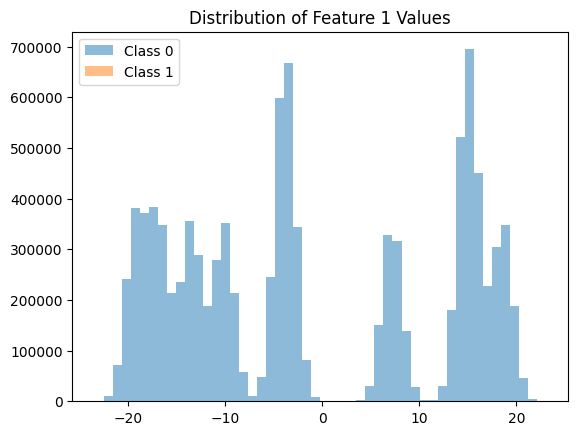

In [ ]:
# flatten time dimension
f1_class0 = X[y == 0,:,0].flatten()
f1_class1 = X[y == 1,:,0].flatten()

plt.hist(f1_class0, bins=50, alpha=0.5, label="Class 0")
plt.hist(f1_class1, bins=50, alpha=0.5, label="Class 1")

plt.title("Distribution of Feature 1 Values")
plt.legend()
plt.show()

# since there are almost million class 0 and approx 700 class 1 samples, the histogram is dominated by class 0 distribution. To better visualize class 1 distribution, we will use density normalization

Fix for fair comparison

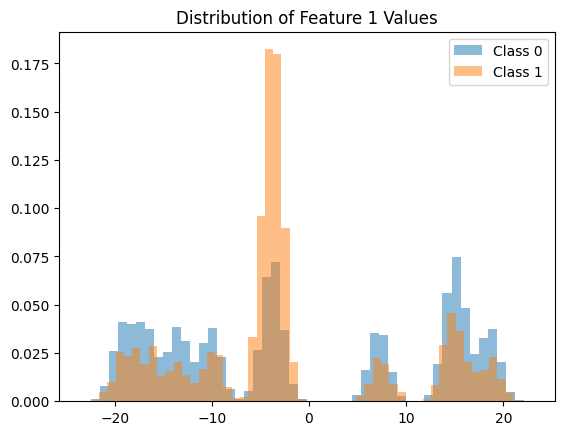

In [ ]:
# Use density normalization:
plt.hist(f1_class0, bins=50, alpha=0.5, label="Class 0", density=True)
plt.hist(f1_class1, bins=50, alpha=0.5, label="Class 1", density=True)

plt.title("Distribution of Feature 1 Values")
plt.legend()
plt.show()

# "Density normalization scales the histogram so that we compare probability distributions rather than raw counts, which is useful when the classes are imbalanced."

##### Temporal Change Analysis

In addition to comparing average values and variability, it is useful to analyze how strongly the sequence changes from one timestep to the next.

This helps determine whether class 1 patterns differ in terms of temporal transitions, such as sharper drops or recoveries across time.

Compute time differences

- Analyze how features change between consecutive timestamps and compare the average temporal pattern between classes

In [38]:
# Compute difference between consecutive timestamps (t1-t0, t2-t1, ...)
diffs = np.diff(X, axis=1)   # Since 10 timestamps give only 9 gaps, shape becomes: (batch, 9, 2)

# Separate temporal differences by class
diff_class0 = diffs[y == 0]  # differences for class 0 samples
diff_class1 = diffs[y == 1]  # differences for class 1 samples

# Check overall min and max change values in each class (sanity check for scale/spikes)
print("Shape of diffs:", diffs.shape)
print("Class 0 diff range:", diff_class0.min(), diff_class0.max())
print("Class 1 diff range:", diff_class1.min(), diff_class1.max())

Shape of diffs: (999991, 9, 2)
Class 0 diff range: -42.7558556616749 42.80540016561581
Class 1 diff range: -40.660969109672195 39.53451432841832


Mean change pattern by class

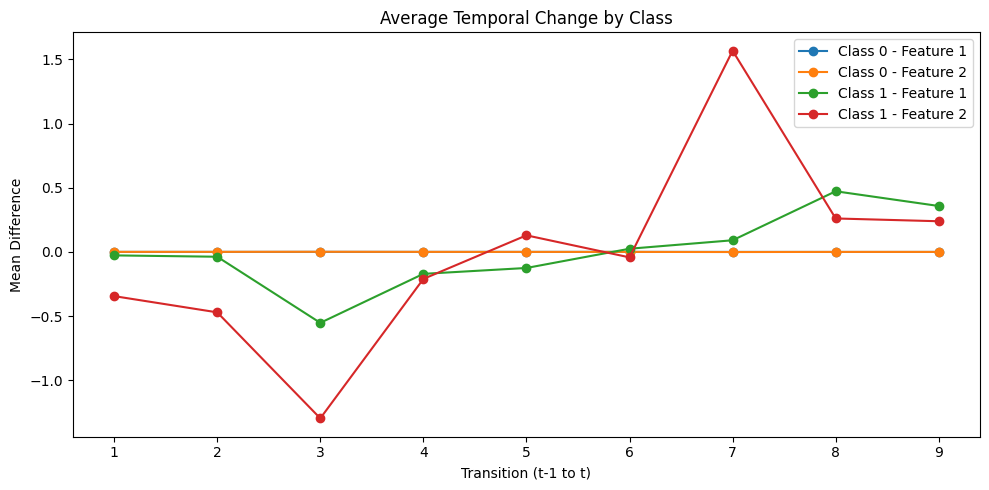

In [ ]:
# Compute average temporal change across all samples for each class axis=0 averages across the sample dimension
diff0_mean = diff_class0.mean(axis=0)   # shape (9, 2)
diff1_mean = diff_class1.mean(axis=0)   # shape (9, 2)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), diff0_mean[:, 0], marker="o", label="Class 0 - Feature 1")
plt.plot(range(1, 10), diff0_mean[:, 1], marker="o", label="Class 0 - Feature 2")
plt.plot(range(1, 10), diff1_mean[:, 0], marker="o", label="Class 1 - Feature 1")
plt.plot(range(1, 10), diff1_mean[:, 1], marker="o", label="Class 1 - Feature 2")

plt.title("Average Temporal Change by Class")
plt.xlabel("Transition (t-1 to t)")    # timestamp transitions
plt.ylabel("Mean Difference")          # average feature change
plt.legend()
plt.tight_layout()
plt.show()

# Blue line (Class 0 - Feature 1) overlaps with the orange line because the average change is ~0, so both curves lie on the same horizontal level and appear as a single line.

##### Pattern Summary

The exploratory analysis shows that class 1 sequences have a structured temporal pattern that differs from class 0.

Key findings:
- Class 0 remains relatively stable across timesteps.
- Class 1 shows a noticeable valley-shaped dip in the middle timesteps (approximately 3 to 6).
- The temporal difference analysis confirms a drop into the middle region followed by recovery afterward.

These findings suggest that the classification problem can be addressed using features that capture:
- overall level
- variability
- minimum/maximum values
- middle-window behavior
- temporal changes between consecutive timesteps

#### Feature Engineering

##### Create Feature Extraction Function

In [ ]:
def make_features(X):
    # Separate the two features across all timesteps
    f1 = X[:, :, 0]      # shape (samples, 10)
    f2 = X[:, :, 1]

    # Compute temporal differences between consecutive timesteps
    # This captures how quickly the sequence changes
    d1 = np.diff(f1, axis=1)
    d2 = np.diff(f2, axis=1)

    features = pd.DataFrame({
        # overall statistics
        # Capture general level and spread of each feature
        "f1_mean": f1.mean(axis=1),
        "f1_std": f1.std(axis=1),
        "f1_min": f1.min(axis=1),
        "f1_max": f1.max(axis=1),
        "f1_range": f1.max(axis=1) - f1.min(axis=1),

        "f2_mean": f2.mean(axis=1),
        "f2_std": f2.std(axis=1),
        "f2_min": f2.min(axis=1),
        "f2_max": f2.max(axis=1),
        "f2_range": f2.max(axis=1) - f2.min(axis=1),

        # middle-window features (important because pattern is in the middle)
        # roughly around timesteps 3 to 6
        "f1_mid_mean": f1[:, 3:7].mean(axis=1),
        "f1_mid_min": f1[:, 3:7].min(axis=1),
        "f2_mid_mean": f2[:, 3:7].mean(axis=1),
        "f2_mid_min": f2[:, 3:7].min(axis=1),

        # first-half vs second-half / shape summary
        # Compare first half vs second half of the sequence
        "f1_first_half_mean": f1[:, :5].mean(axis=1),
        "f1_second_half_mean": f1[:, 5:].mean(axis=1),
        "f1_half_diff": f1[:, 5:].mean(axis=1) - f1[:, :5].mean(axis=1),

        "f2_first_half_mean": f2[:, :5].mean(axis=1),
        "f2_second_half_mean": f2[:, 5:].mean(axis=1),
        "f2_half_diff": f2[:, 5:].mean(axis=1) - f2[:, :5].mean(axis=1),

        # endpoints / coarse slope
        # Difference between last and first timestep
        "f1_last_minus_first": f1[:, -1] - f1[:, 0],
        "f2_last_minus_first": f2[:, -1] - f2[:, 0],

        # temporal change features
         # Capture volatility and sudden jumps in the sequence
        "f1_diff_mean": d1.mean(axis=1),
        "f1_diff_std": d1.std(axis=1),
        "f1_diff_min": d1.min(axis=1),
        "f1_diff_max": d1.max(axis=1),
        "f1_abs_diff_max": np.abs(d1).max(axis=1),

        "f2_diff_mean": d2.mean(axis=1),
        "f2_diff_std": d2.std(axis=1),
        "f2_diff_min": d2.min(axis=1),
        "f2_diff_max": d2.max(axis=1),
        "f2_abs_diff_max": np.abs(d2).max(axis=1),

        # cross-feature relationship
        # Compare feature1 and feature2 behaviour
        "overall_gap_mean": (f1 - f2).mean(axis=1),
        "mid_gap_mean": (f1[:, 3:7] - f2[:, 3:7]).mean(axis=1),
    })

    return features

Now create the feature table:

In [41]:
X_feat = make_features(X)
print(X_feat.shape)
X_feat.head()

(999991, 34)


,f1_mean,f1_std,f1_min,f1_max,f1_range,f2_mean,f2_std,f2_min,f2_max,f2_range,...,f1_diff_min,f1_diff_max,f1_abs_diff_max,f2_diff_mean,f2_diff_std,f2_diff_min,f2_diff_max,f2_abs_diff_max,overall_gap_mean,mid_gap_mean
0,-6.340849,9.307585,-19.037,7.371232,26.408232,-0.601422,9.466184,-9.919501,17.746859,27.666360,...,-25.799656,16.989088,25.799656,-0.746174,11.145849,-18.767753,26.332274,26.332274,-5.739427,-16.719810
1,-8.632189,8.428832,-19.037,6.330312,25.367312,-0.959110,9.577188,-9.919501,17.746859,27.666360,...,-16.930171,16.989088,16.989088,-0.047330,11.170316,-18.767753,26.332274,26.332274,-7.673079,-16.342256
2,-8.121467,7.961560,-19.037,6.330312,25.367312,1.469638,11.167310,-9.919501,19.189805,29.109306,...,-16.930171,15.872862,16.930171,3.234367,13.401319,-18.767753,26.332274,26.332274,-9.591106,-9.752088
3,-9.037189,7.661293,-19.037,6.330312,25.367312,2.340657,10.568660,-9.628940,19.189805,28.818745,...,-16.930171,15.872862,16.930171,0.935514,15.343009,-20.399118,26.332274,26.332274,-11.377846,0.718577
4,-9.064830,7.639187,-19.037,6.330312,25.367312,2.218553,10.712322,-10.849981,19.189805,30.039786,...,-16.930171,15.872862,16.930171,-3.061479,12.656785,-20.399118,24.713451,24.713451,-11.283383,-1.250241


In [47]:
X_feat["target"] = y
X_feat.head()

,f1_mean,f1_std,f1_min,f1_max,f1_range,f2_mean,f2_std,f2_min,f2_max,f2_range,...,f1_diff_max,f1_abs_diff_max,f2_diff_mean,f2_diff_std,f2_diff_min,f2_diff_max,f2_abs_diff_max,overall_gap_mean,mid_gap_mean,target
0,-6.340849,9.307585,-19.037,7.371232,26.408232,-0.601422,9.466184,-9.919501,17.746859,27.666360,...,16.989088,25.799656,-0.746174,11.145849,-18.767753,26.332274,26.332274,-5.739427,-16.719810,0.0
1,-8.632189,8.428832,-19.037,6.330312,25.367312,-0.959110,9.577188,-9.919501,17.746859,27.666360,...,16.989088,16.989088,-0.047330,11.170316,-18.767753,26.332274,26.332274,-7.673079,-16.342256,0.0
2,-8.121467,7.961560,-19.037,6.330312,25.367312,1.469638,11.167310,-9.919501,19.189805,29.109306,...,15.872862,16.930171,3.234367,13.401319,-18.767753,26.332274,26.332274,-9.591106,-9.752088,0.0
3,-9.037189,7.661293,-19.037,6.330312,25.367312,2.340657,10.568660,-9.628940,19.189805,28.818745,...,15.872862,16.930171,0.935514,15.343009,-20.399118,26.332274,26.332274,-11.377846,0.718577,0.0
4,-9.064830,7.639187,-19.037,6.330312,25.367312,2.218553,10.712322,-10.849981,19.189805,30.039786,...,15.872862,16.930171,-3.061479,12.656785,-20.399118,24.713451,24.713451,-11.283383,-1.250241,0.0


##### Engineered Features

The engineered features are designed to capture the discovered class-1 pattern.

In particular, the feature set includes:
- overall summary statistics
- middle-window features to detect the valley-shaped dip
- first-vs-second-half summaries
- temporal difference features to capture sharp drops and recoveries
- cross-feature gap features

These features convert each sequence of shape `(10, 2)` into a fixed-length tabular representation suitable for classical machine learning models.

##### Train-Test Split

To evaluate model performance on unseen data, the dataset is divided into a training set and a test set.

Since the dataset is highly imbalanced, **stratified splitting** is used to preserve the class distribution in both sets.

- Training data: 80%
- Test data: 20%

In [49]:
# Import train-test split function
from sklearn.model_selection import train_test_split

# Separate features and target
X_model = X_feat.drop(columns=["target"])
y_model = X_feat["target"]

# Perform stratified train-test split
# Stratification ensures the rare class distribution is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    stratify=y_model,
    random_state=42
)

# Print dataset sizes
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verify class distribution after split
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (799992, 34)
Test shape: (199999, 34)

Train class distribution:
target
0.0    0.999307
1.0    0.000693
Name: proportion, dtype: float64

Test class distribution:
target
0.0    0.999305
1.0    0.000695
Name: proportion, dtype: float64


##### Model Selection Strategy

Two models are evaluated:

1. **Logistic Regression**
   - Simple baseline model
   - Requires feature scaling

2. **Random Forest**
   - Non-linear model capable of capturing complex patterns
   - Handles feature interactions naturally

Because the dataset is highly imbalanced, **class weighting** is used to penalize misclassification of the rare class.

To obtain reliable performance estimates, **Stratified K-Fold Cross Validation** is used.

Evaluation metrics:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC (important for rare-event detection)

Define models

In [52]:
# Import required libraries for modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define models

models = {

    # Logistic Regression with scaling
    # Scaling is required because logistic regression is sensitive to feature magnitudes
    "logistic_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",   # handle class imbalance
            max_iter=2000,
            random_state=42
        ))
    ]),

    # Random Forest classifier
    # Good for capturing non-linear relationships
    "random_forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced_subsample",  # adjusts weights for rare class
        n_jobs=-1,
        random_state=42
    )
}


##### Cross Validation

To reduce randomness in model evaluation, **Stratified 3-Fold Cross Validation** is applied on the training set.

This ensures:

- each fold preserves class imbalance
- model evaluation is more stable

In [53]:
# Import cross validation utilities
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# Define stratified k-fold
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Define evaluation metrics
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

# Store cross validation results
cv_results = []

# Loop through models
for name, model in models.items():

    print(f"Running cross validation for: {name}")

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # Store mean metrics
    cv_results.append({
        "model": name,
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "pr_auc_mean": scores["test_pr_auc"].mean()
    })

# Convert results to dataframe
cv_results_df = pd.DataFrame(cv_results)

# Sort by PR-AUC (important for rare classes)
cv_results_df = cv_results_df.sort_values("pr_auc_mean", ascending=False)

cv_results_df

Running cross validation for: logistic_regression
Running cross validation for: random_forest


,model,precision_mean,recall_mean,f1_mean,roc_auc_mean,pr_auc_mean
1,random_forest,0.009495,0.713024,0.018741,0.956909,0.032901
0,logistic_regression,0.004567,0.904328,0.009089,0.945050,0.023062


##### Cross Validation Results Interpretation

The dataset is extremely imbalanced (~0.07% positive class), which makes metrics such as accuracy misleading.

The evaluation focuses on **PR-AUC**, **Recall**, and **F1-score**.

Observations:

- Random Forest achieves the highest PR-AUC.
- Logistic Regression has higher recall but extremely low precision.
- Random Forest provides a better balance between recall and precision.

Therefore, **Random Forest is selected as the final model**.

Train the final model 

In [55]:
# Select the best performing model
best_model = models["random_forest"]

# Train the model using the full training dataset
best_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Evaluate on the Test set

In [56]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score

# Predict class labels
y_pred = best_model.predict(X_test)

# Predict probabilities (needed for ROC and PR metrics)
y_prob = best_model.predict_proba(X_test)[:,1]

# Print detailed classification metrics
print(classification_report(y_test, y_pred, digits=4))

# Additional evaluation metrics
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0     0.9998    0.9380    0.9679    199860
         1.0     0.0080    0.7194    0.0158       139

    accuracy                         0.9378    199999
   macro avg     0.5039    0.8287    0.4919    199999
weighted avg     0.9991    0.9378    0.9672    199999

ROC-AUC: 0.9538663755276175
PR-AUC: 0.02801134595005936
Confusion Matrix:
[[187461  12399]
 [    39    100]]


Plot Confusion matrix

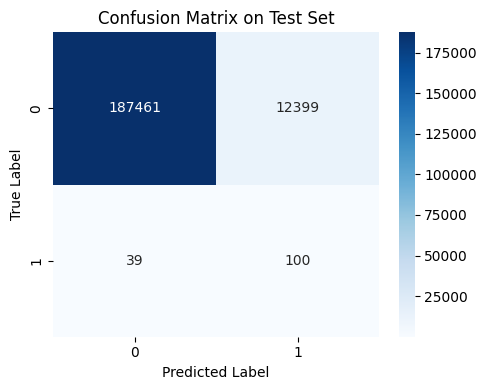

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Feature importance 

In [58]:
# Extract feature importance from the trained Random Forest

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

# Display top features
feature_importance.head(15)

,feature,importance
1,f1_std,0.222317
13,f2_mid_min,0.143308
23,f1_diff_std,0.101531
12,f2_mid_mean,0.055092
5,f2_mean,0.044730
11,f1_mid_min,0.033162
10,f1_mid_mean,0.032385
0,f1_mean,0.029647
7,f2_min,0.025355
24,f1_diff_min,0.021603


Plot feature importance 

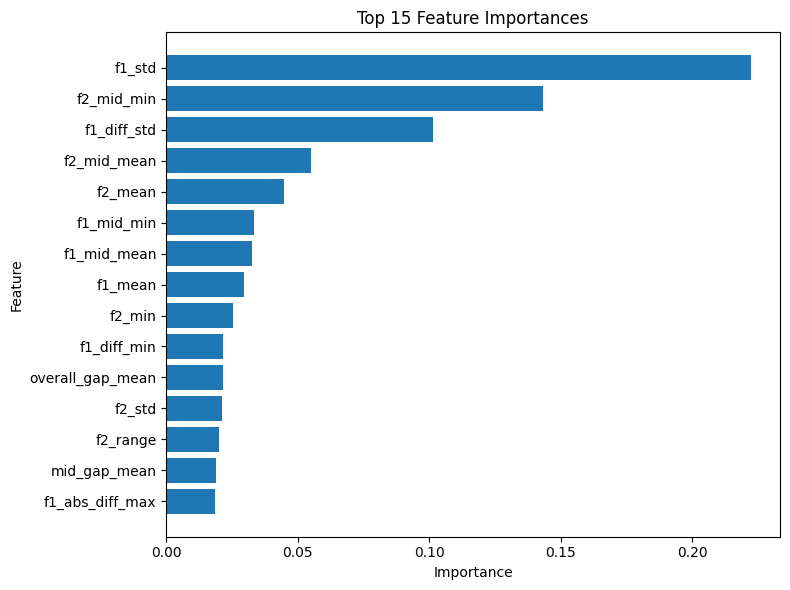

In [59]:
# Select top 15 most important features
top_features = feature_importance.head(15)

# Plot feature importances
plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])

# Invert y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Feature Analysis – Patterns Used by the Model

The feature importance analysis provides insight into which characteristics of the time series are most useful for distinguishing class 1 samples from class 0.

Several groups of features stand out:

##### 1. Variability Features
The most important feature is `f1_std`, which measures the standard deviation of feature 1 across the time sequence.  
This indicates that **class 1 sequences tend to have higher variability** compared to class 0.

##### 2. Middle-Window Features
Features such as:

- `f2_mid_min`
- `f2_mid_mean`
- `f1_mid_min`
- `f1_mid_mean`

focus specifically on the **middle timesteps (3–6)** of the sequence.

These features confirm the pattern observed during exploratory analysis:  
class 1 sequences often exhibit a **dip or valley in the middle of the time series**.

##### 3. Temporal Change Features
Features like:

- `f1_diff_std`
- `f1_diff_min`
- `f1_abs_diff_max`

measure **changes between consecutive timesteps**.

These features suggest that class 1 sequences involve **stronger temporal transitions**, such as sharper drops and recoveries.

##### 4. Cross-Feature Relationships
Features such as:

- `overall_gap_mean`
- `mid_gap_mean`

capture the relationship between the two signals.  
This indicates that the **relative difference between the two features** also contributes to identifying class 1 patterns.

##### Summary

The model primarily distinguishes class 1 samples using:

- higher variability
- a **middle-region dip pattern**
- stronger temporal transitions
- relationships between the two features

These findings align with the patterns observed during exploratory analysis, confirming that the engineered features successfully capture the discriminative temporal structure.

#### Model Selection

Two models were evaluated during the modeling phase:

- Logistic Regression
- Random Forest

Because the dataset is extremely imbalanced, model performance was evaluated using:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Among these metrics, **PR-AUC (Average Precision)** is the most informative for rare-event detection.

##### Cross-Validation Findings

Random Forest achieved the highest PR-AUC and a better balance between recall and precision compared to Logistic Regression.

Logistic Regression achieved slightly higher recall but produced very low precision, indicating that it generated too many false positive predictions.

##### Final Model Choice

Based on cross-validation results and the ability to capture non-linear temporal patterns, **Random Forest was selected as the final model**.

This model is well suited for the engineered features because it can capture complex interactions between statistical summaries, temporal differences, and middle-window behavior.

#### Production Readiness and Limitations

The trained Random Forest model demonstrates the ability to detect rare class-1 sequences using temporal patterns discovered during exploratory analysis.

##### Strengths

- The model captures the middle-timestep dip pattern observed during feature analysis.
- Engineered features summarize important characteristics of the time series, including variability, temporal changes, and relationships between the two signals.
- Cross-validation was used to reduce randomness in model evaluation.

##### Limitations

- The dataset is extremely imbalanced, which leads to low precision and a large number of false positives.
- The model relies on the specific temporal patterns observed in the training data.
- If future sequences exhibit different patterns, model performance may degrade.

##### Handling New or Unseen Patterns

If new samples contain patterns not seen during training:

- the model may fail to detect them correctly
- periodic retraining with updated data would be required
- monitoring metrics such as PR-AUC, recall, and false positive rate would be important in production

#### Conclusion

This project addressed a time-series classification problem where each sample consists of 10 temporal observations with two features.

Exploratory analysis revealed that class-1 samples exhibit a distinctive valley-shaped pattern in the middle timesteps, along with stronger temporal transitions compared to class-0 samples.

Feature engineering was designed to capture:

- statistical properties of the sequence
- middle-window behavior
- temporal differences between consecutive timesteps
- relationships between the two signals

Using these engineered features, machine learning models were trained and compared using stratified cross-validation. Random Forest achieved the best performance and was selected as the final model.

The results demonstrate that engineered temporal features can effectively detect rare patterns in time-series data while also highlighting the importance of careful evaluation in highly imbalanced datasets.